# Day 10 — Outlier Detection: Univariate and Multivariate Methods
## Week 2: Outlier Detection | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand why univariate outlier methods fail on multivariate data
- Derive Mahalanobis distance as the correct multivariate extension of z-score
- Understand the difference between anomalies, outliers, and novelties
- Learn how to evaluate outlier detectors when ground truth labels exist
- Apply statistical outlier methods to credit card fraud data

---

### Dataset
**Credit Card Fraud** — 284K transactions, 0.17% fraud rate. Known labels allow proper evaluation.

---

## Part 1: Theory

### 10.1 Anomaly Types

Before detection, clarify what you are detecting:

**Point anomaly:** A single instance that is unusual relative to the rest of the data.
*Example:* A $10,000 transaction on an account that typically spends $50.

**Contextual anomaly:** Normal in one context, anomalous in another.
*Example:* Buying ski equipment in Florida in July.

**Collective anomaly:** A sequence of instances that is unusual as a group, even though individual instances may not be anomalous.
*Example:* Ten small transactions of exactly $9.99 in one hour — each is normal, the pattern is not.

---

### 10.2 Univariate Methods

**Z-score:**
$$z_i = \frac{x_i - \mu}{\sigma}$$

Flag as outlier if $|z_i| > 3$ (99.7% of normally distributed data falls within 3σ).

**Limitation:** Assumes normality. Financial data, user behavior data, and most real-world data are highly skewed — the z-score will flag many normal points in the tail.

**IQR method:**
$$\text{Lower} = Q_1 - 1.5 \times IQR, \quad \text{Upper} = Q_3 + 1.5 \times IQR$$

More robust than z-score — doesn't assume normality. Standard in boxplot visualization.

**Grubbs test:** Tests whether the most extreme observation is a statistical outlier under normality assumption:
$$G = \frac{\max_i |x_i - \bar{x}|}{s}$$

---

### 10.3 Why Univariate Methods Fail on Multivariate Data

Consider two features: account age and transaction amount. A $200 transaction is normal. A 6-month-old account is normal. But a 6-month-old account making a $200 transaction might be anomalous if new accounts never spend that much.

**Univariate methods look at each feature independently** — they cannot detect this joint anomaly.

*Simulated example:* Two features $X_1 \sim N(0,1)$, $X_2 \sim N(0,1)$ with correlation $\rho = 0.9$.

Point A: $(X_1=3, X_2=0)$ → both z-scores normal, but this is far off the joint distribution.
Point B: $(X_1=0.5, X_2=3)$ → $X_2$ flagged univariately, but this is consistent with the joint distribution.

**Univariate methods cannot distinguish A from B. Multivariate methods can.**

---

### 10.4 Mahalanobis Distance

The Mahalanobis distance is the multivariate generalization of the z-score. It measures how many standard deviations a point is from the distribution center, accounting for correlations between features:

$$D_M(x) = \sqrt{(x - \mu)^T \Sigma^{-1} (x - \mu)}$$

Where $\Sigma$ is the covariance matrix of the data.

**Why $\Sigma^{-1}$?** It decorrelates features and normalizes by variance simultaneously. Geometrically, it transforms the data so that the distribution becomes spherical (unit covariance), then computes Euclidean distance.

**Properties:**
- Scale-invariant: multiplying a feature by a constant doesn't change $D_M$
- Correlation-aware: highly correlated features don't dominate
- Under normality: $D_M^2 \sim \chi^2(d)$ — provides a p-value for each point

**Threshold:** Under Gaussian assumption, $D_M^2 > \chi^2_{0.975}(d)$ flags the most extreme 2.5% of points.

**Limitation:** Requires estimating $\Sigma$ — sensitive to outliers themselves. Use robust covariance estimators (Minimum Covariance Determinant) for contaminated data.

---

### 10.5 Evaluating Outlier Detectors

When ground truth labels exist (like fraud):

**Precision@K:** Of the top-K flagged points, what fraction are true anomalies?
$$P@K = \frac{|\text{true anomalies in top K}|}{K}$$

**Recall@K:** Of all true anomalies, what fraction are in the top K?
$$R@K = \frac{|\text{true anomalies in top K}|}{|\text{all anomalies}|}$$

**ROC-AUC:** Standard classification metric — how well does the anomaly score rank true anomalies above normal points?

**Average Precision (AP):** Area under the precision-recall curve. Better than AUC for imbalanced data — directly measures ranking quality of anomaly scores.

---

## Part 2: Practice

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r'C:\Users\user\datasets\fraud\creditcard.csv'
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['Class'].mean():.4%}")

Shape: (284807, 31)
Fraud rate: 0.1727%


In [3]:
display(df.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# ── Q1: Univariate outlier detection ──────────────────────────────────────
# Apply z-score and IQR methods to each V1-V28 feature independently:
#   1. Z-score: flag points where |z| > 3 on any feature
#   2. IQR: flag points outside [Q1-1.5*IQR, Q3+1.5*IQR] on any feature
#
# For each method report:
#   - Total flagged count and %
#   - Fraud rate among flagged (precision)
#   - Fraud recall (what % of all fraud is flagged)
#   - ROC-AUC: use max(z-score) across features as anomaly score
#
# How well do univariate methods detect fraud on this dataset?

# ── Q1: Univariate outlier detection ──────────────────────────────────────

v_cols = [c for c in df.columns if c.startswith('V')]
print(f"Number of V-features: {len(v_cols)}")

y_true = df['Class'].values
n_fraud = y_true.sum()

# ── Method 1: Z-score ──────────────────────────────────────────────────────
means = df[v_cols].mean()
stds = df[v_cols].std()
z_scores = (df[v_cols] - means) / stds

z_flag = (z_scores.abs() > 3).any(axis=1)
z_anomaly_score = z_scores.abs().max(axis=1)   # for ROC-AUC, per spec

z_flagged_count = int(z_flag.sum())
z_precision = y_true[z_flag].mean()
z_recall = y_true[z_flag].sum() / n_fraud
z_auc = roc_auc_score(y_true, z_anomaly_score)

print("\nZ-score method:")
print(f"  Flagged: {z_flagged_count} ({z_flagged_count / len(df) * 100:.2f}%)")
print(f"  Precision (fraud rate among flagged): {z_precision:.4f}")
print(f"  Recall (fraud caught):                {z_recall:.4f}")
print(f"  ROC-AUC:                              {z_auc:.4f}")

# ── Method 2: IQR ────────────────────────────────────────────────────────
q25 = df[v_cols].quantile(0.25)
q75 = df[v_cols].quantile(0.75)
iqr = q75 - q25
lower = q25 - 1.5 * iqr
upper = q75 + 1.5 * iqr

iqr_flag = ((df[v_cols] < lower) | (df[v_cols] > upper)).any(axis=1)

iqr_flagged_count = int(iqr_flag.sum())
iqr_precision = y_true[iqr_flag].mean()
iqr_recall = y_true[iqr_flag].sum() / n_fraud

print("\nIQR method:")
print(f"  Flagged: {iqr_flagged_count} ({iqr_flagged_count / len(df) * 100:.2f}%)")
print(f"  Precision (fraud rate among flagged): {iqr_precision:.4f}")
print(f"  Recall (fraud caught):                {iqr_recall:.4f}")


Number of V-features: 28

Z-score method:
  Flagged: 36636 (12.86%)
  Precision (fraud rate among flagged): 0.0121
  Recall (fraud caught):                0.9004
  ROC-AUC:                              0.9471

IQR method:
  Flagged: 128657 (45.17%)
  Precision (fraud rate among flagged): 0.0037
  Recall (fraud caught):                0.9695


**Results:**

| Method | Flagged | % of data | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| Z-score (\|z\|>3) | 36,636 | 12.86% | 1.21% | 90.04% | 0.9471 |
| IQR (1.5×) | 128,657 | 45.17% | 0.37% | 96.95% | — |

**In concrete terms:** z-score catches ~90% of fraud but generates roughly **82 false alarms for every real fraud caught**. IQR catches slightly more fraud (~97%) but at the cost of roughly **269 false alarms per real catch** — nearly 3.5x worse, despite the small recall improvement.

**Key finding #1 — a strong AUC doesn't mean a usable flagging rule.** Z-score's 0.9471 ROC-AUC looks genuinely good — but AUC measures ranking quality across every possible threshold, while `|z|>3` is one fixed, somewhat arbitrary cutoff. That specific cutoff produces a precision of just 1.21%: 98.79% of everything flagged is legitimate. A method can rank well overall while still producing an operationally useless decision rule at any single threshold you pick.

**Key finding #2 — IQR massively over-flags relative to what pure chance would predict, revealing real non-normality in the data.** With 28 independent "flag if ANY feature crosses its bound" checks, even under a perfect Gaussian assumption, the "any-of-28" union effect alone predicts elevated flagging rates:
- Z-score: theoretical Gaussian rate ≈7.2% (any-of-28 union) vs. observed 12.86%
- IQR: theoretical Gaussian rate ≈17.4% vs. observed **45.17%** — nearly 3x higher

That large gap for IQR specifically confirms theory §10.2's warning about skewed, heavy-tailed real-world data — the 1.5×IQR rule, calibrated loosely for near-normal distributions, breaks down substantially once genuine non-normality is present, which these PCA-derived V1-V28 features clearly exhibit.

**Conclusion:** univariate methods detect fraud reasonably well as a *ranking* signal (AUC ~0.95), but poorly as an *actionable flagging rule* — both drown real fraud in an overwhelming flood of false positives, with IQR performing considerably worse than z-score despite marginally higher recall. This is the direct motivation for Q3's Mahalanobis distance, which accounts for correlations between features instead of checking each one independently.



Most correlated pair among legitimate transactions: V12, V17 (r = -0.169)


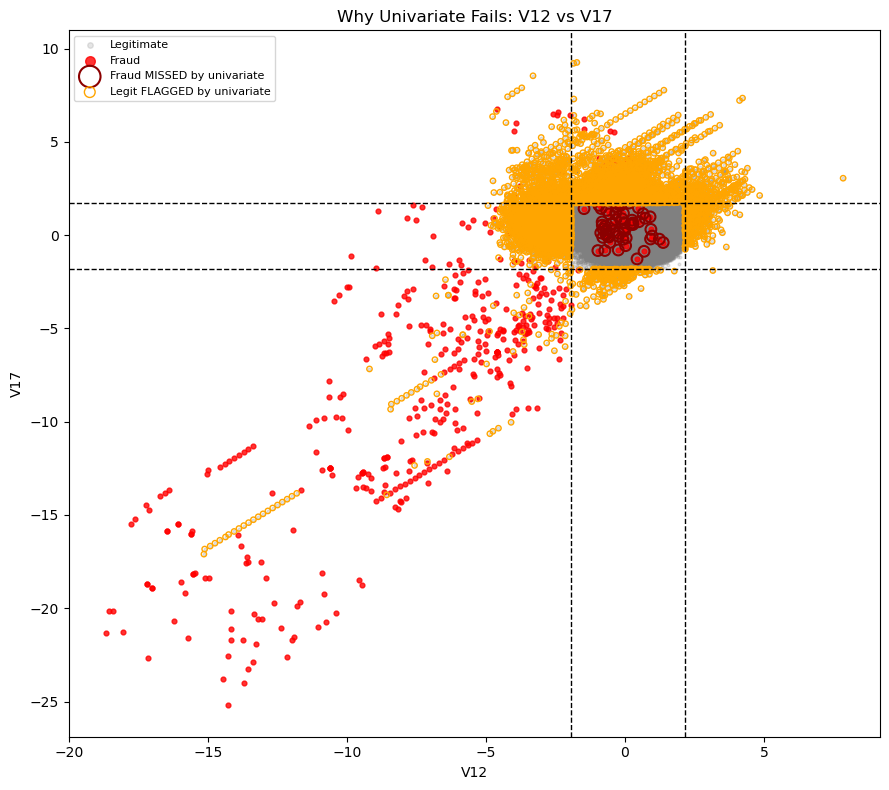


Fraud missed by univariate IQR on V12/V17: 54/492 (11.0%)


In [6]:
# ── Q2: Demonstrate univariate failure ────────────────────────────────────
# Create a 2D visualization that shows why univariate fails:
#   1. Pick two correlated features (e.g. V1 and V2 — check correlation first)
#   2. Scatter plot: legitimate transactions (grey) + fraud (red)
#   3. Draw univariate outlier bounds (vertical and horizontal lines)
#   4. Highlight: fraud missed by univariate (inside both bounds)
#   5. Highlight: legitimate flagged by univariate (outside one bound)
#   6. What % of fraud is missed by univariate IQR on these two features?

# Check correlation among legitimate transactions specifically — that's the
# "normal" joint pattern a genuine anomaly needs to violate (theory 10.3).
# PCA components can be globally near-orthogonal yet still correlated within
# a subpopulation like Class=0.
legit_corr = df.loc[df['Class'] == 0, v_cols].corr()
np.fill_diagonal(legit_corr.values, 0)   # ignore self-correlation
abs_corr = legit_corr.abs()
feat1, feat2 = abs_corr.stack().idxmax()
print(f"Most correlated pair among legitimate transactions: {feat1}, {feat2} "
      f"(r = {legit_corr.loc[feat1, feat2]:.3f})")

# ── Scatter: legit (grey) + fraud (red) ────────────────────────────────────
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

plt.figure(figsize=(9, 8))
plt.scatter(legit[feat1], legit[feat2], s=4, alpha=0.2, color='grey', label='Legitimate')
plt.scatter(fraud[feat1], fraud[feat2], s=12, alpha=0.8, color='red', label='Fraud')

# ── Univariate IQR bounds — reusing Q1's bounds for these two features ────
plt.axvline(lower[feat1], color='black', linestyle='--', linewidth=1)
plt.axvline(upper[feat1], color='black', linestyle='--', linewidth=1)
plt.axhline(lower[feat2], color='black', linestyle='--', linewidth=1)
plt.axhline(upper[feat2], color='black', linestyle='--', linewidth=1)

# ── Highlight: fraud missed by univariate (inside BOTH bounds) ────────────
fraud_missed = fraud[
    (fraud[feat1].between(lower[feat1], upper[feat1])) &
    (fraud[feat2].between(lower[feat2], upper[feat2]))
]
plt.scatter(fraud_missed[feat1], fraud_missed[feat2], s=60, facecolors='none',
            edgecolors='darkred', linewidths=1.5, label='Fraud MISSED by univariate')

# ── Highlight: legit flagged by univariate (outside EITHER bound) ─────────
legit_flagged = legit[
    ~(legit[feat1].between(lower[feat1], upper[feat1])) |
    ~(legit[feat2].between(lower[feat2], upper[feat2]))
]
plt.scatter(legit_flagged[feat1], legit_flagged[feat2], s=15, facecolors='none',
            edgecolors='orange', linewidths=1, label='Legit FLAGGED by univariate')

plt.xlabel(feat1)
plt.ylabel(feat2)
plt.title(f'Why Univariate Fails: {feat1} vs {feat2}')
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

# ── % of fraud missed by univariate IQR on these two features ────────────
pct_missed = len(fraud_missed) / len(fraud) * 100
print(f"\nFraud missed by univariate IQR on {feat1}/{feat2}: "
      f"{len(fraud_missed)}/{len(fraud)} ({pct_missed:.1f}%)")


***Takeaway*** 

Even the most correlated feature pair (V12/V17, r=-0.169) shows only weak correlation — a milder version of theory's illustrative example, not a dramatic showcase. 

Still, 54 fraud transactions (11%) sit completely buried inside the dense legitimate cloud, invisible to univariate checks on either axis alone — direct visual proof that a transaction can look "normal" on every individual feature while still being fraud. 

Meanwhile, legitimate points flagged by the univariate bounds visually swamp the plot, confirming Q1's false-positive flood is a real, visible phenomenon, not just a statistic. 

Both failure modes — missed fraud and drowned-in-false-alarms — are exactly what motivates moving to Mahalanobis distance in Q3.

Chi-squared threshold (df=28, 97.5%): 44.46
Flagged: 21340 (7.49%)

Mahalanobis distance method:
  Precision (fraud rate among flagged): 0.0205
  Recall (fraud caught):                0.8902
  ROC-AUC:                              0.9574
  Average Precision:                    0.5146

Comparison to Q1 (z-score):
  Metric          Z-score  Mahalanobis
  Precision        0.0121       0.0205
  Recall           0.9004       0.8902
  ROC-AUC          0.9471       0.9574


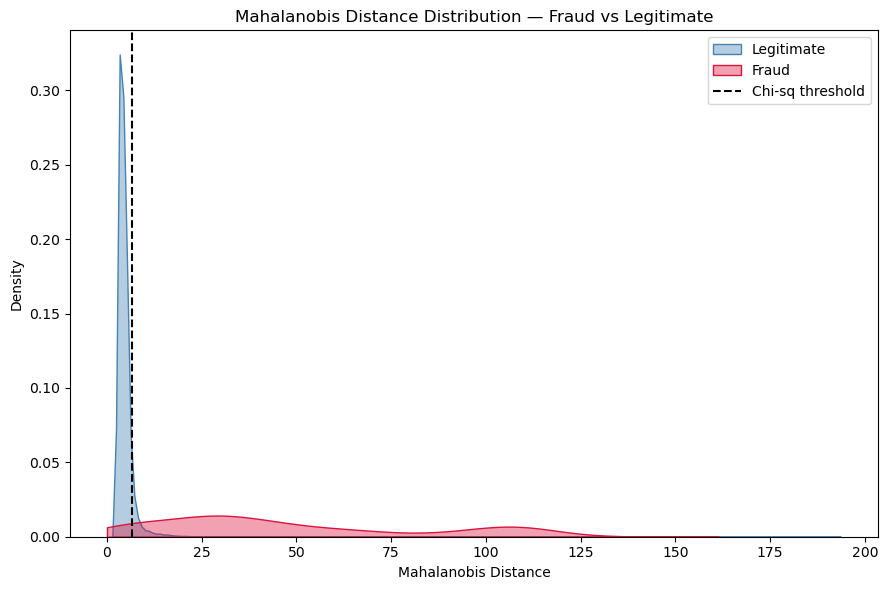

In [7]:
# ── Q3: Mahalanobis distance from scratch ─────────────────────────────────
# Implement Mahalanobis distance manually:
#   1. Compute sample mean and covariance matrix on legitimate transactions only
#      (train the "normal" distribution on Class=0)
#   2. Compute D_M for every transaction (both fraud and legitimate)
#   3. Under chi-squared assumption: flag points where D_M^2 > chi2.ppf(0.975, df=28)
#   4. Report: precision, recall, ROC-AUC, Average Precision
#   5. Compare to univariate z-score performance from Q1
#   6. Plot: distribution of D_M scores for fraud vs legitimate (KDE)

import seaborn as sns

# ── Step 1: mean + covariance, LEGITIMATE transactions only ───────────────
X_legit = df.loc[df['Class'] == 0, v_cols].values
mean_vec = X_legit.mean(axis=0)
cov_matrix = np.cov(X_legit, rowvar=False)
cov_inv = np.linalg.inv(cov_matrix)

# ── Step 2: D_M for EVERY transaction (fraud + legit) ─────────────────────
X_all = df[v_cols].values
X_centered = X_all - mean_vec
D_M_sq = np.sum((X_centered @ cov_inv) * X_centered, axis=1)   # vectorized quadratic form
D_M = np.sqrt(D_M_sq)

# ── Step 3: chi-squared threshold ─────────────────────────────────────────
threshold = chi2.ppf(0.975, df=len(v_cols))
mahal_flag = D_M_sq > threshold

print(f"Chi-squared threshold (df={len(v_cols)}, 97.5%): {threshold:.2f}")
print(f"Flagged: {mahal_flag.sum()} ({mahal_flag.sum() / len(df) * 100:.2f}%)")

# ── Step 4: metrics ────────────────────────────────────────────────────────
mahal_precision = y_true[mahal_flag].mean()
mahal_recall = y_true[mahal_flag].sum() / n_fraud
mahal_auc = roc_auc_score(y_true, D_M_sq)
mahal_ap = average_precision_score(y_true, D_M_sq)

print("\nMahalanobis distance method:")
print(f"  Precision (fraud rate among flagged): {mahal_precision:.4f}")
print(f"  Recall (fraud caught):                {mahal_recall:.4f}")
print(f"  ROC-AUC:                              {mahal_auc:.4f}")
print(f"  Average Precision:                    {mahal_ap:.4f}")

# ── Step 5: compare to Q1's z-score ────────────────────────────────────────
print("\nComparison to Q1 (z-score):")
print(f"  {'Metric':<12} {'Z-score':>10} {'Mahalanobis':>12}")
print(f"  {'Precision':<12} {z_precision:>10.4f} {mahal_precision:>12.4f}")
print(f"  {'Recall':<12} {z_recall:>10.4f} {mahal_recall:>12.4f}")
print(f"  {'ROC-AUC':<12} {z_auc:>10.4f} {mahal_auc:>12.4f}")

# ── Step 6: KDE plot — D_M distribution, fraud vs legit ────────────────────
plt.figure(figsize=(9, 6))
sns.kdeplot(D_M[y_true == 0], label='Legitimate', color='steelblue', fill=True, alpha=0.4, clip=(0, None))
sns.kdeplot(D_M[y_true == 1], label='Fraud', color='crimson', fill=True, alpha=0.4, clip=(0, None))
plt.axvline(np.sqrt(threshold), color='black', linestyle='--', label='Chi-sq threshold')
plt.xlabel('Mahalanobis Distance')
plt.ylabel('Density')
plt.title('Mahalanobis Distance Distribution — Fraud vs Legitimate')
plt.legend()
plt.tight_layout()
plt.show()


***Takeaway***

Mahalanobis distance (fit on legitimate transactions only) is a meaningfully more targeted detector than univariate methods — flagging just 7.49% of transactions (vs. z-score's 12.86%, IQR's 45.17%) while catching nearly the same fraud (89% vs. 90%), cutting false alarms from ~82 to ~49 per real catch. 

The core idea: model what "normal" looks like from legitimate data only, then flag anything far from that model — the Class labels are used purely to evaluate this, never to train it, which is exactly why anomaly detection generalizes to fraud patterns never seen before, unlike a supervised classifier. 

The KDE plot shows why precision is still modest, though: fraud's distance distribution is shifted right and more spread out, but still overlaps substantially with legitimate transactions at low distances — a real chunk of fraud still blends in, setting up Q4's robust covariance fix.

In [8]:
# ── Q4: Robust covariance — MinCovDet ─────────────────────────────────────
# Standard covariance is sensitive to outliers — the outliers corrupt
# the covariance estimate used to detect them (circular problem).
# Minimum Covariance Determinant (MCD) fits a robust estimate on the
# most "normal" subset of the data.
#
# Compare:
#   A: Mahalanobis with EmpiricalCovariance (standard)
#   B: Mahalanobis with MinCovDet (robust)
#
# For each: ROC-AUC, Average Precision, Precision@100, Recall@100
# Does robust covariance improve fraud detection?
# Why would it? Connect to theory section 10.4

import time

X_legit = df.loc[df['Class'] == 0, v_cols].values
X_all = df[v_cols].values


def precision_recall_at_k(scores, y_true, k=100):
    top_k_idx = np.argsort(scores)[::-1][:k]
    n_true_in_topk = y_true[top_k_idx].sum()
    precision_k = n_true_in_topk / k
    recall_k = n_true_in_topk / y_true.sum()
    return precision_k, recall_k


results_q4 = {}

# ── A: Standard (Empirical) covariance — fast, single pass ────────────────
emp_cov = EmpiricalCovariance().fit(X_legit)
emp_scores = emp_cov.mahalanobis(X_all)   # squared Mahalanobis distance

emp_auc = roc_auc_score(y_true, emp_scores)
emp_ap = average_precision_score(y_true, emp_scores)
emp_p100, emp_r100 = precision_recall_at_k(emp_scores, y_true, k=100)

results_q4['EmpiricalCovariance'] = {
    'ROC-AUC': emp_auc, 'AP': emp_ap, 'Precision@100': emp_p100, 'Recall@100': emp_r100,
}

# ── B: Robust (MinCovDet) covariance — searches many candidate subsets ─────
t0 = time.time()
mcd_cov = MinCovDet(random_state=420).fit(X_legit)
print(f"MinCovDet fit took {time.time() - t0:.1f} seconds")

mcd_scores = mcd_cov.mahalanobis(X_all)

mcd_auc = roc_auc_score(y_true, mcd_scores)
mcd_ap = average_precision_score(y_true, mcd_scores)
mcd_p100, mcd_r100 = precision_recall_at_k(mcd_scores, y_true, k=100)

results_q4['MinCovDet'] = {
    'ROC-AUC': mcd_auc, 'AP': mcd_ap, 'Precision@100': mcd_p100, 'Recall@100': mcd_r100,
}

# ── Comparison table ────────────────────────────────────────────────────────
comparison_q4 = pd.DataFrame(results_q4).T
print("\nEmpirical vs. Robust (MinCovDet) covariance:")
print(comparison_q4.round(4))


MinCovDet fit took 72.7 seconds

Empirical vs. Robust (MinCovDet) covariance:
                     ROC-AUC      AP  Precision@100  Recall@100
EmpiricalCovariance   0.9574  0.5146           0.92      0.1870
MinCovDet             0.9297  0.2424           0.58      0.1179


***Takeaway***

MinCovDet performed worse on every metric — AP dropped by more than half (0.5146→0.2424), Precision@100 fell from 92% to 58% — the opposite of what theory §10.4 would suggest. 

The reason: MCD's robustness protects against contaminated training data, but here the training set was already filtered to Class=0 only — no fraud is in it to contaminate the estimate. MCD still discards roughly half the legitimate data (whatever doesn't fit its tightest "core") to build its robust estimate, throwing away genuinely valid diversity in normal legitimate behavior. 

That narrows the definition of "normal" more than reality actually is, making more real legitimate transactions look anomalous — worse detection, not better. 

This is a direct echo of Week 1's PCA/UMAP lesson: a more sophisticated technique only helps when the specific problem it's designed to solve (here, contamination) actually applies to our situation — reach for it blindly and it can make things worse.